# Exam Answer Sheet Image Preprocessing and OCR

# Imports

Import everything needed for preprocessing, augmentation, visualization, OCR, and grid handling.

In [1]:
# Import the libraries used throughout the notebook.
from __future__ import annotations

from pathlib import Path
from typing import Iterable

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
from paddleocr import PaddleOCR
import tqdm as notebook_tqdm

plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.titleweight'] = 'bold'

def show_image(image, title: str, cmap: str | None = None) -> None:
    # Render an image with matplotlib and hide axes for cleaner notebook output.
    plt.figure()
    if image.ndim == 3 and image.shape[2] == 3 and cmap is None:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(image, cmap=cmap or 'gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

def show_grid(images: list[np.ndarray], titles: list[str], cols: int = 2) -> None:
    # Display a small gallery of images in a fixed grid.
    rows = int(np.ceil(len(images) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = np.array(axes).reshape(-1)
    for idx, ax in enumerate(axes):
        ax.axis('off')
        if idx < len(images):
            image = images[idx]
            if image.ndim == 3 and image.shape[2] == 3:
                ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
            else:
                ax.imshow(image, cmap='gray')
            ax.set_title(titles[idx])
    plt.tight_layout()
    plt.show()

def ensure_bgr(image: np.ndarray) -> np.ndarray:
    # Convert grayscale images to BGR so OpenCV drawing and OCR inputs stay consistent.
    if image.ndim == 2:
        return cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    return image.copy()

def find_test_image() -> Path:
    # Look for the first image in the datasets folder.
    # Start from current working directory and navigate to datasets
    current_dir = Path.cwd()
    
    # Try multiple possible paths to the datasets folder
    possible_paths = [
        current_dir / 'datasets',
        current_dir.parent / 'datasets',
        Path('/workspaces/ocr/datasets'),
    ]
    
    for datasets_path in possible_paths:
        if datasets_path.exists():
            for pattern in ('*.png', '*.jpg', '*.jpeg', '*.webp', '*.bmp', '*.tif', '*.tiff'):
                matches = sorted(datasets_path.rglob(pattern))
                if matches:
                    return matches[0]
    
    raise FileNotFoundError(f'No image files found in datasets. Searched: {possible_paths}')

def load_test_image() -> np.ndarray:
    # Load the first available image from the datasets folder.
    image_path = find_test_image()
    loaded = cv2.imread(str(image_path))
    if loaded is not None:
        print(f'Loaded test image from: {image_path}')
        return loaded
    raise IOError(f'Failed to load image from {image_path}')

/opt/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Preprocessing


Loaded test image from: /workspaces/ocr/datasets/realtesting/1.jpeg


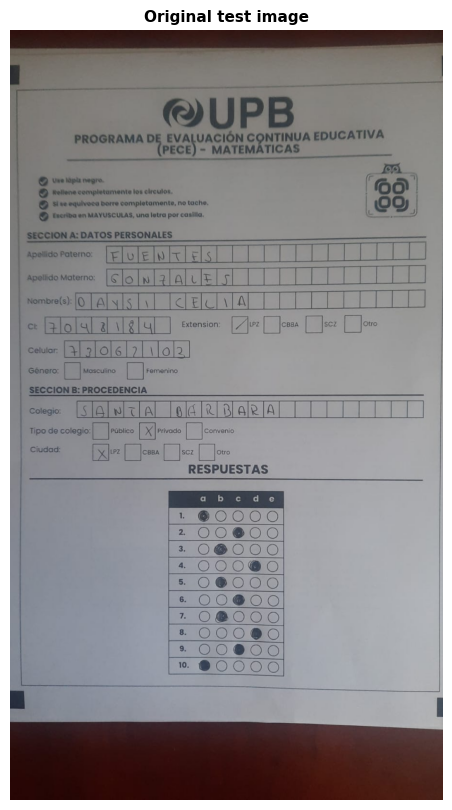

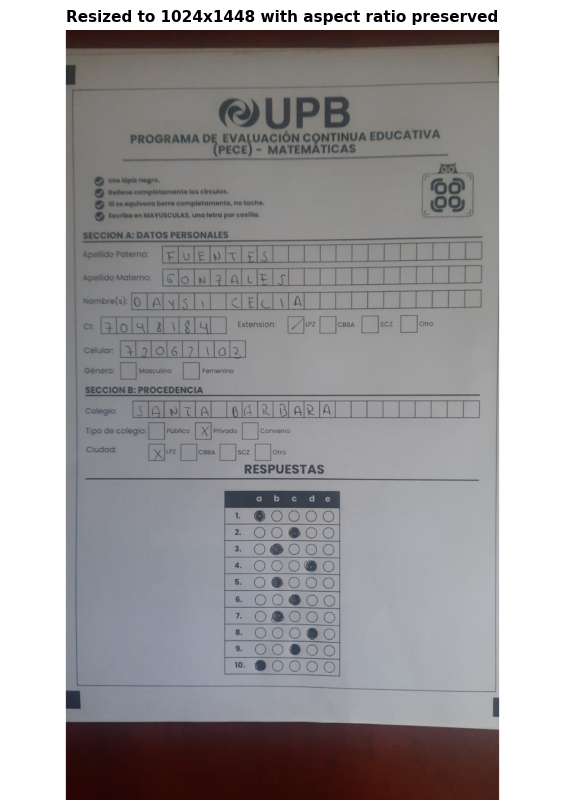

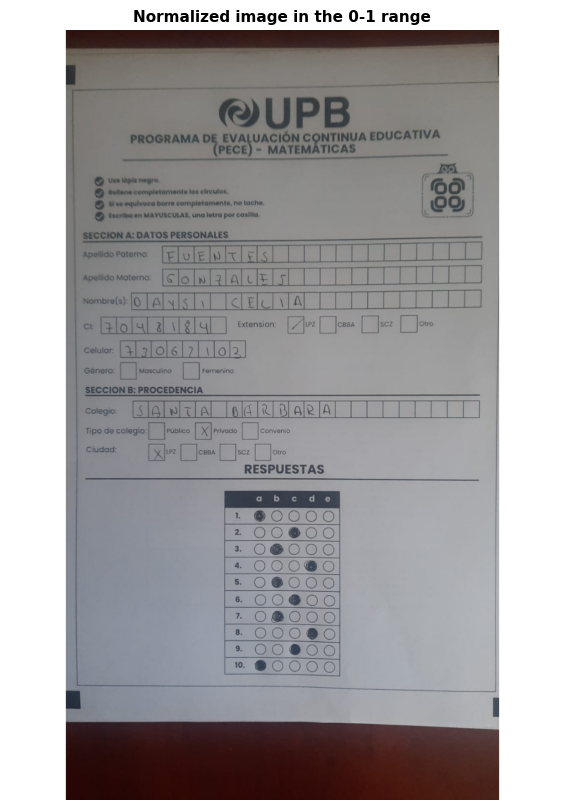

In [2]:
# Load the image that will flow through the rest of the notebook.
test_image_bgr = load_test_image()
show_image(test_image_bgr, 'Original test image')

# Resize while preserving aspect ratio by scaling and padding to the requested target size.
target_width, target_height = 1024, 1448
scale = min(target_width / test_image_bgr.shape[1], target_height / test_image_bgr.shape[0])
new_width = int(round(test_image_bgr.shape[1] * scale))
new_height = int(round(test_image_bgr.shape[0] * scale))
resized = cv2.resize(test_image_bgr, (new_width, new_height), interpolation=cv2.INTER_AREA)
canvas = np.full((target_height, target_width, 3), 255, dtype=np.uint8)
y_offset = (target_height - new_height) // 2
x_offset = (target_width - new_width) // 2
canvas[y_offset:y_offset + new_height, x_offset:x_offset + new_width] = resized
resized_bgr = canvas
show_image(resized_bgr, 'Resized to 1024x1448 with aspect ratio preserved')

# Normalize the image into the 0-1 range for downstream analysis and visualization.
normalized = resized_bgr.astype(np.float32) / 255.0
show_image(normalized, 'Normalized image in the 0-1 range')

# Keep a convenient OCR-ready version for later steps.
ocr_ready_bgr = resized_bgr.copy()

## Section 3 - Data Augmentation

/tmp/ipykernel_8504/1605622111.py:3: UserWarning: Argument(s) 'fill_value' are not valid for transform Rotate
  A.Rotate(limit=5, fill_value=(255, 255, 255), border_mode=cv2.BORDER_CONSTANT, p=0.9),


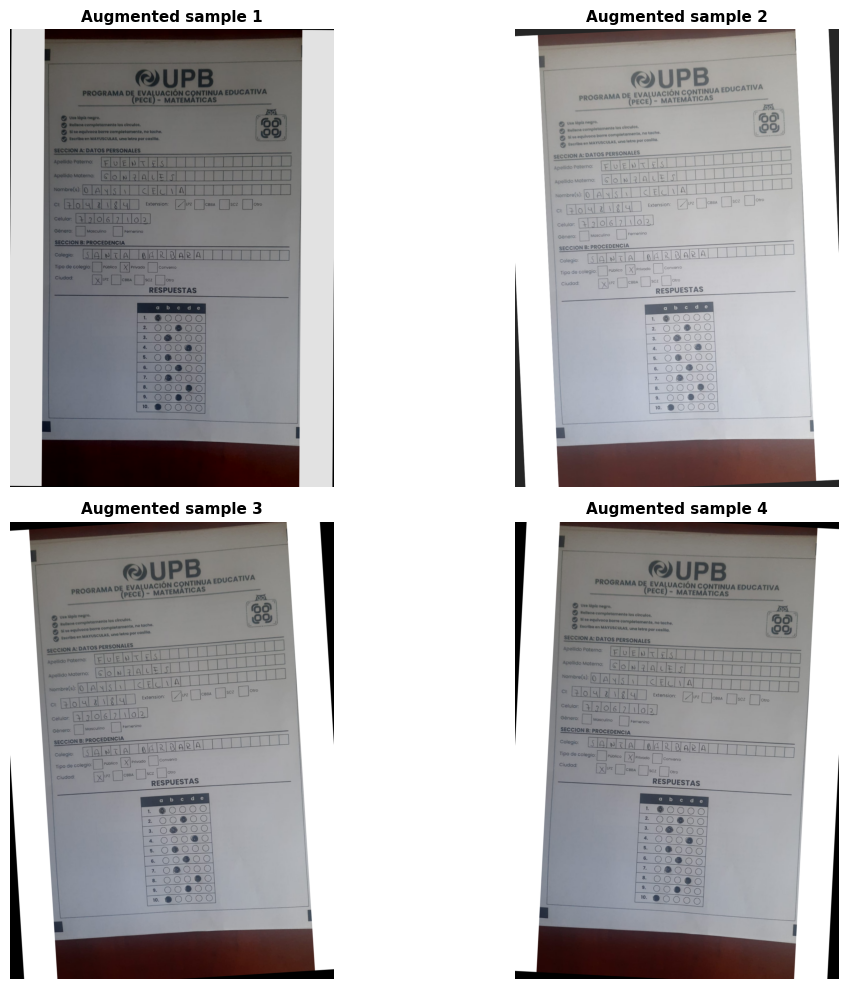

In [11]:
# Build a light augmentation pipeline with rotation and brightness shift.
augmentation = A.Compose([
    A.Rotate(limit=5, fill_value=(255, 255, 255), border_mode=cv2.BORDER_CONSTANT, p=0.9),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.0, p=0.8),
])

# Generate four distinct variants of the same image to preview the augmentation range.
augmented_images = []
augmented_titles = []
for index in range(4):
    augmented = augmentation(image=ocr_ready_bgr)['image']
    augmented_images.append(augmented)
    augmented_titles.append(f'Augmented sample {index + 1}')

show_grid(augmented_images, augmented_titles, cols=2)

## OCR with PaddleOCR

Initialize PaddleOCR with DBNet for text detection and a Transformer-based recognizer, run OCR on the preprocessed image, draw bounding boxes, and print structured results as dictionaries containing text, bbox, and confidence.

Creating model: ('PP-OCRv5_mobile_det', None, 'paddle_dynamic')
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/ubuntu/.paddlex/official_models/PP-OCRv5_mobile_det_safetensors`.
Loading configuration file /home/ubuntu/.paddlex/official_models/PP-OCRv5_mobile_det_safetensors/config.json
Loading weights file /home/ubuntu/.paddlex/official_models/PP-OCRv5_mobile_det_safetensors/model.safetensors
Loaded weights file from disk, setting weights to model.
All model checkpoint weights were used when initializing PPOCRV5MobileDet.

All the weights of PPOCRV5MobileDet were initialized from the model checkpoint at /home/ubuntu/.paddlex/official_models/PP-OCRv5_mobile_det_safetensors.
If your task is similar to the task the model of the checkpoint was trained on, you can already use PPOCRV5MobileDet for predictions without further training.
Creating model: ('PP-OCRv5_mobile_rec', None, 'paddle_dynamic')
Model files already exist. Using cac

Using explicit PaddleOCR models: PP-OCRv5_mobile_det + PP-OCRv5_mobile_rec (paddle_dynamic).


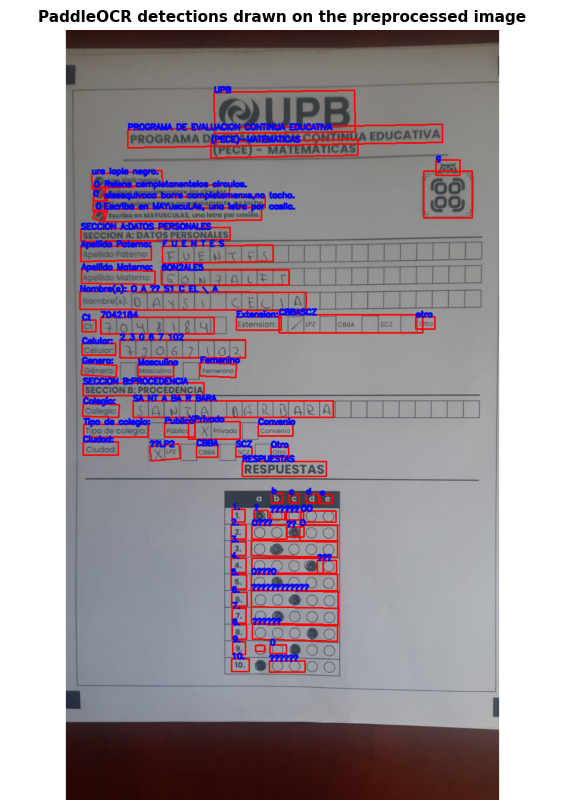

[{'text': 'UPB', 'bbox': [[383, 117], [647, 113], [648, 191], [384, 194]], 'confidence': 0.9731809496879578}, {'text': 'PROGRAMA DE EVALUACION CONTINUA EDUCATIVA', 'bbox': [[221, 187], [812, 177], [812, 211], [221, 221]], 'confidence': 0.9574740529060364}, {'text': '(PECE)-MATEMATICAS', 'bbox': [[377, 210], [653, 205], [653, 235], [377, 240]], 'confidence': 0.9417397975921631}, {'text': 'g', 'bbox': [[800, 244], [845, 244], [845, 273], [800, 273]], 'confidence': 0.06754908710718155}, {'text': 'ure laple negro.', 'bbox': [[153, 270], [285, 264], [286, 292], [154, 298]], 'confidence': 0.8562679290771484}, {'text': '', 'bbox': [[777, 265], [868, 265], [868, 353], [777, 353]], 'confidence': 0.0}, {'text': 'O', 'bbox': [[157, 295], [179, 295], [179, 321], [157, 321]], 'confidence': 0.23365971446037292}, {'text': 'Relene cempletanentelos clrculos.', 'bbox': [[177, 294], [412, 291], [412, 312], [177, 315]], 'confidence': 0.8440507650375366}, {'text': '0', 'bbox': [[156, 312], [182, 312], [182

In [10]:
# Initialize PaddleOCR with explicit DBNet + Transformer-style OCR models.
# Use `paddle_dynamic` engine to avoid static backend issues in this environment.
import os

os.environ['PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK'] = 'True'

ocr_engine = PaddleOCR(
    text_detection_model_name='PP-OCRv5_mobile_det',
    text_recognition_model_name='PP-OCRv5_mobile_rec',
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    enable_hpi=False,
    engine='paddle_dynamic',
)
print('Using explicit PaddleOCR models: PP-OCRv5_mobile_det + PP-OCRv5_mobile_rec (paddle_dynamic).')

# Run OCR with the current API (`predict`) and parse output robustly across versions.
ocr_results = ocr_engine.predict(ocr_ready_bgr)

detections = []
if isinstance(ocr_results, list) and ocr_results:
    first_item = ocr_results[0]

    # Old-style output: list of [bbox, (text, confidence)]
    if isinstance(first_item, list) and first_item and isinstance(first_item[0], (list, tuple)):
        detections = first_item

    # New-style output: list of dicts from `predict`
    elif isinstance(first_item, dict):
        rec_texts = first_item.get('rec_texts', [])
        rec_scores = first_item.get('rec_scores', [])
        dt_polys = first_item.get('dt_polys', [])

        count = min(len(rec_texts), len(rec_scores), len(dt_polys))
        for idx in range(count):
            detections.append([dt_polys[idx], (rec_texts[idx], rec_scores[idx])])

structured_results = []
overlay = ocr_ready_bgr.copy()
for detection in detections:
    if not isinstance(detection, (list, tuple)) or len(detection) < 2:
        continue

    bbox, rec = detection[0], detection[1]
    if not isinstance(rec, (list, tuple)) or len(rec) < 2:
        continue

    text, confidence = rec[0], rec[1]
    bbox_array = np.array(bbox, dtype=np.int32)

    if bbox_array.ndim != 2 or bbox_array.shape[0] < 3:
        continue

    structured_results.append({
        'text': str(text),
        'bbox': [[int(point[0]), int(point[1])] for point in bbox_array.tolist()],
        'confidence': float(confidence),
    })
    cv2.polylines(overlay, [bbox_array], isClosed=True, color=(0, 0, 255), thickness=2)
    cv2.putText(overlay, str(text), tuple(bbox_array[0]), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2, cv2.LINE_AA)

show_image(overlay, 'PaddleOCR detections drawn on the preprocessed image')
print(structured_results)

Grid Handling

Detect the name/data grid with HoughLinesP, infer the grid boundaries, segment it cell by cell, and display the individual cropped cells. This is the part of the notebook that isolates the letter-by-letter zone for later OCR or rule-based extraction.

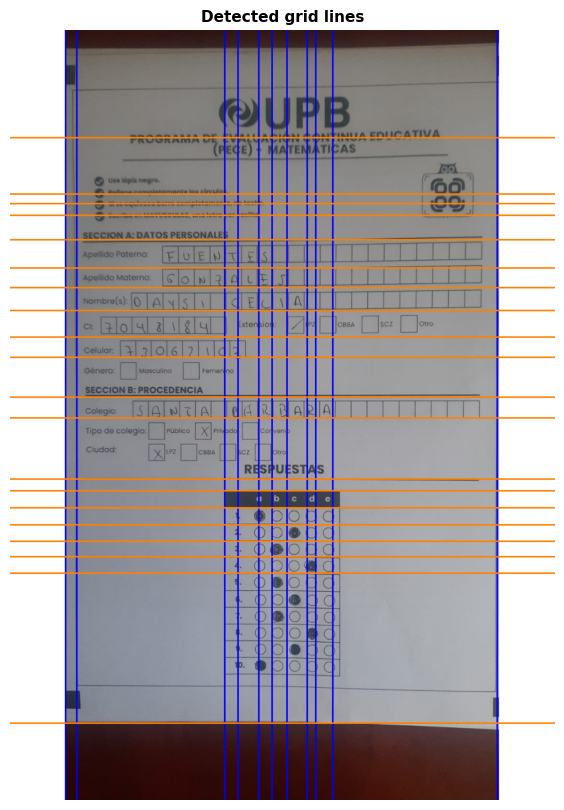

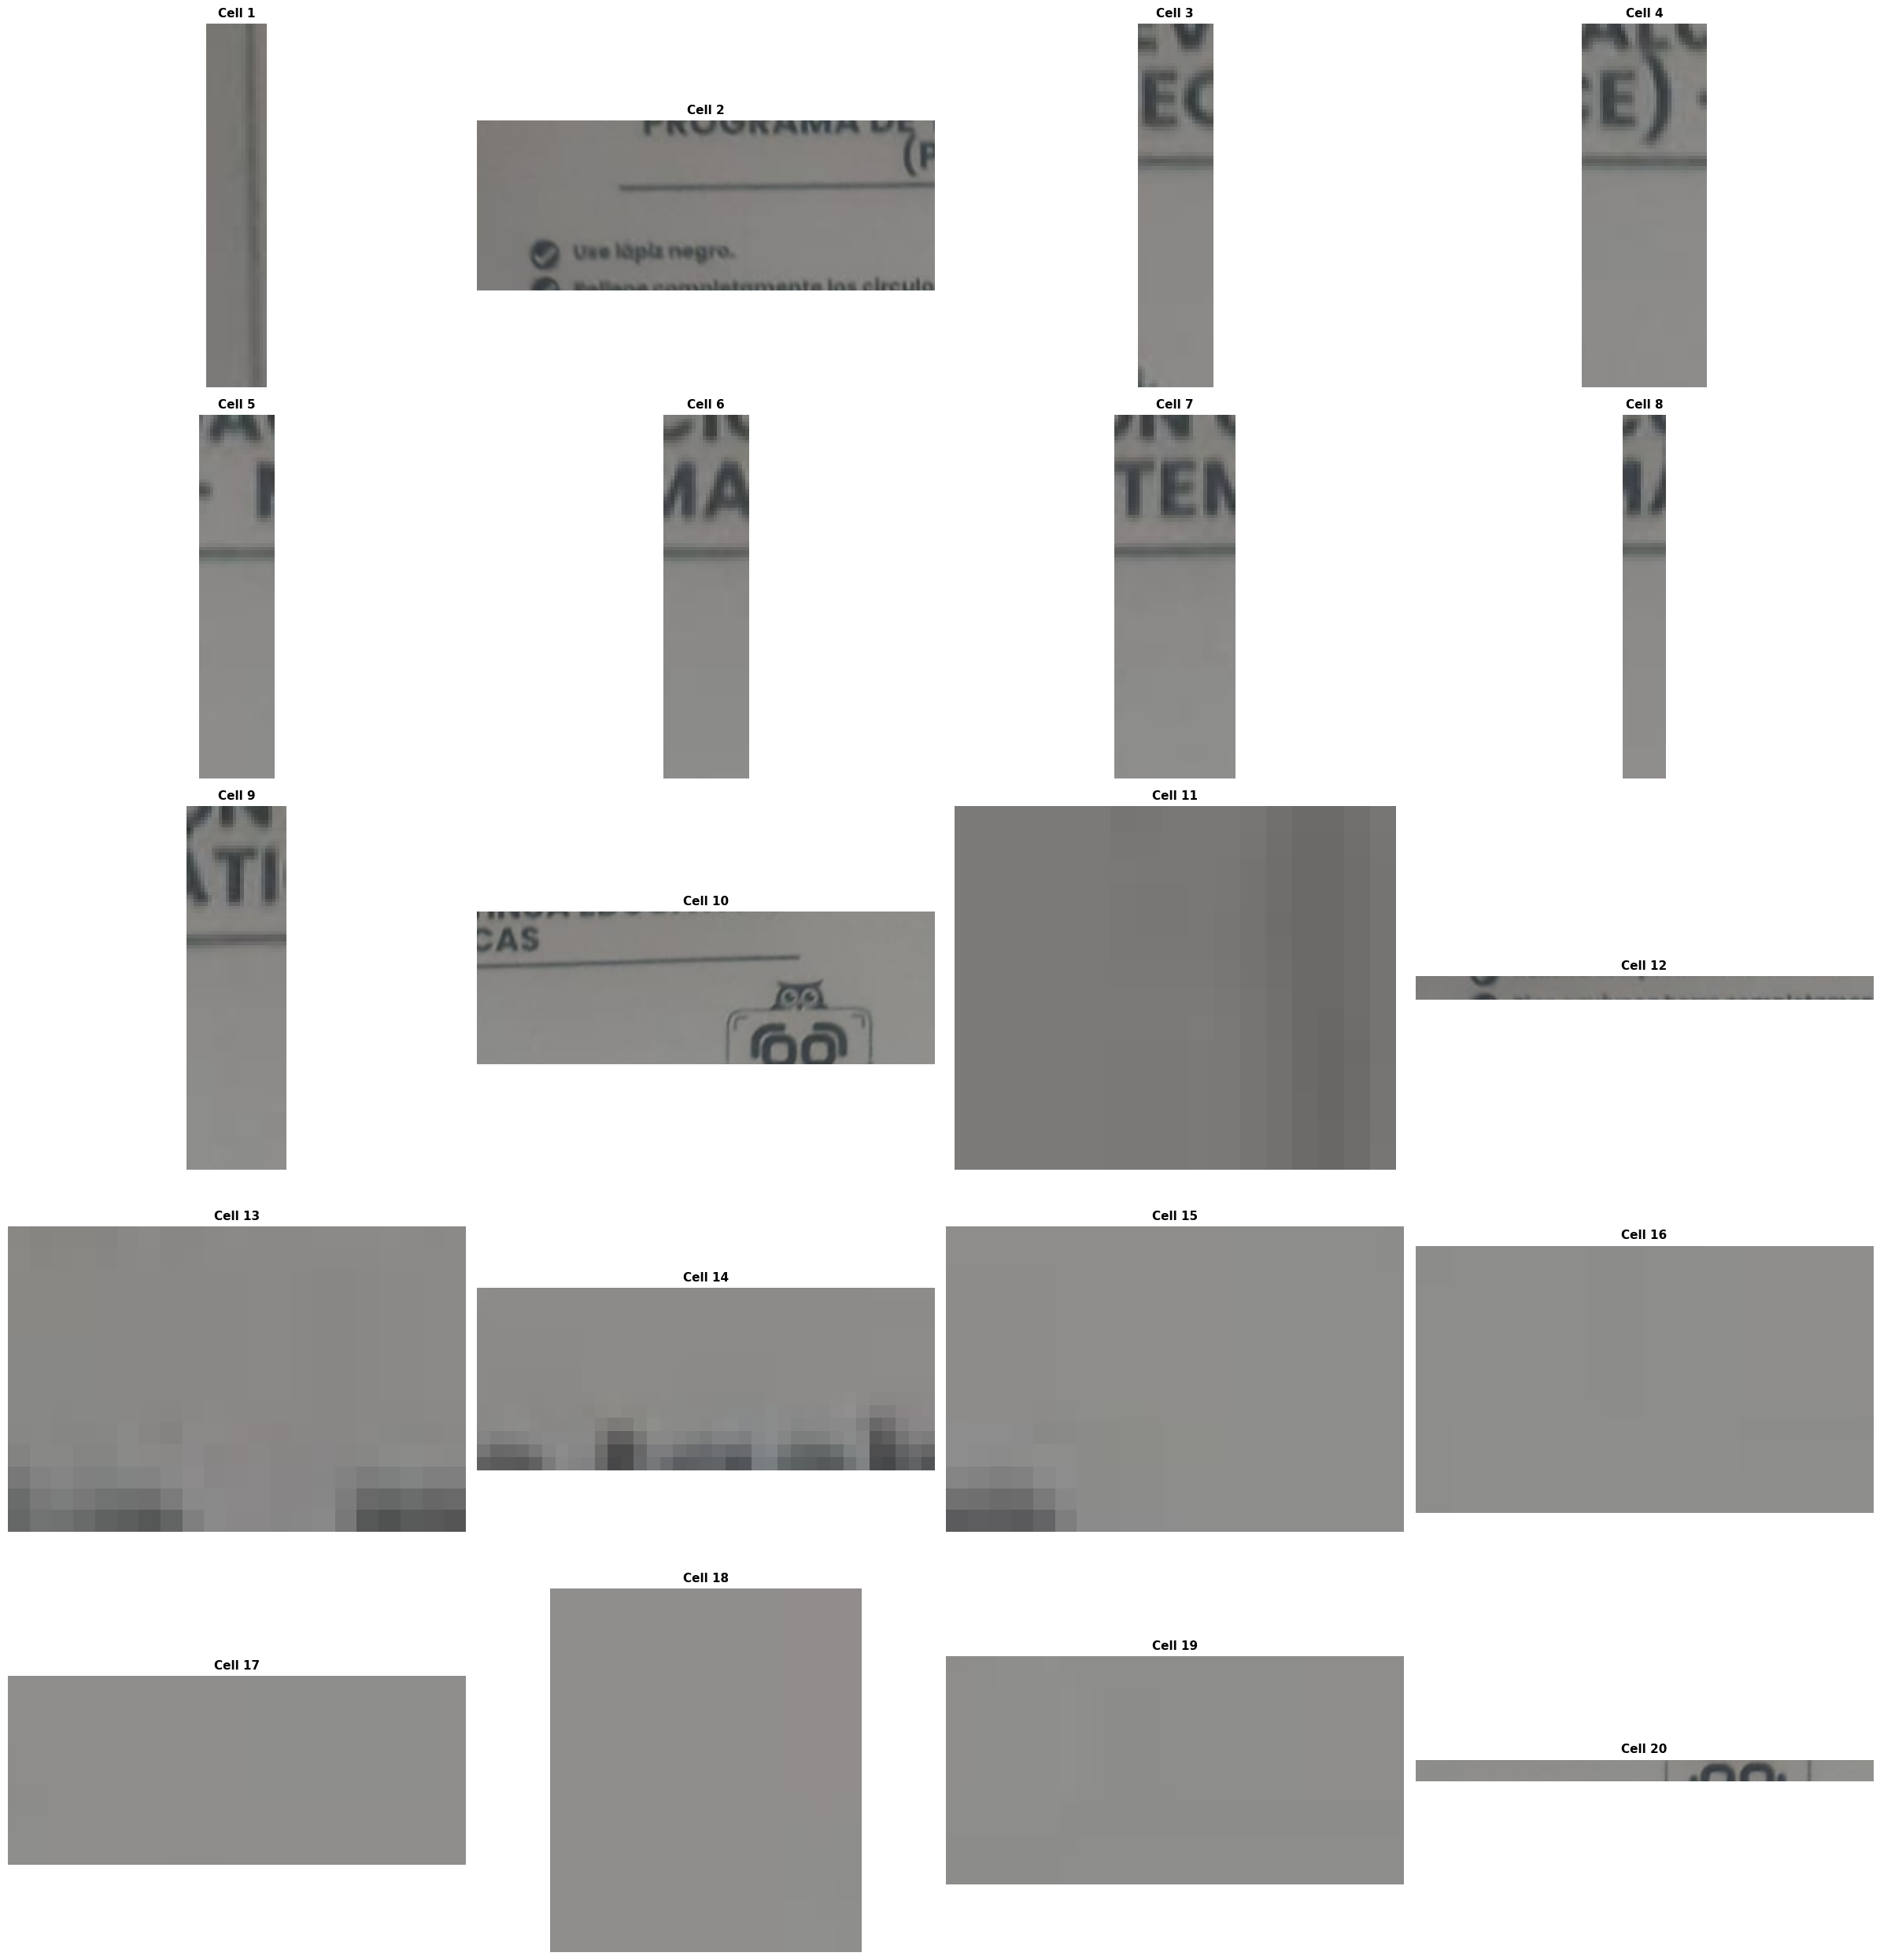

Detected vertical lines: 11
Detected horizontal lines: 20
Cropped cells: 190


In [12]:
# Prepare a binary image that makes the printed grid lines easier to detect.
grid_gray = cv2.cvtColor(ocr_ready_bgr, cv2.COLOR_BGR2GRAY)
grid_blur = cv2.GaussianBlur(grid_gray, (3, 3), 0)
grid_edges = cv2.Canny(grid_blur, 50, 150, apertureSize=3)
grid_lines = cv2.HoughLinesP(grid_edges, 1, np.pi / 180, threshold=120, minLineLength=160, maxLineGap=12)

vertical_positions = []
horizontal_positions = []
if grid_lines is not None:
    for line in grid_lines[:, 0]:
        x1, y1, x2, y2 = line
        if abs(x2 - x1) < 12:
            vertical_positions.append(int(round((x1 + x2) / 2)))
        elif abs(y2 - y1) < 12:
            horizontal_positions.append(int(round((y1 + y2) / 2)))

def cluster_positions(values: Iterable[int], tolerance: int = 10) -> list[int]:
    # Merge nearby Hough detections into single grid line coordinates.
    sorted_values = sorted(int(value) for value in values)
    if not sorted_values:
        return []
    clusters = [[sorted_values[0]]] 
    for value in sorted_values[1:]:
        if abs(value - clusters[-1][-1]) <= tolerance:
            clusters[-1].append(value)
        else:
            clusters.append([value])
    return [int(round(float(np.mean(cluster)))) for cluster in clusters]

vertical_lines = cluster_positions(vertical_positions, tolerance=12)
horizontal_lines = cluster_positions(horizontal_positions, tolerance=12)

# Keep only the strongest interior region if the detector returns extra lines from the page border.
vertical_lines = [x for x in vertical_lines if 50 < x < ocr_ready_bgr.shape[1] - 50]
horizontal_lines = [y for y in horizontal_lines if 180 < y < ocr_ready_bgr.shape[0] - 120]
vertical_lines = sorted(set(vertical_lines))
horizontal_lines = sorted(set(horizontal_lines))

grid_overlay = ocr_ready_bgr.copy()
for x in vertical_lines:
    cv2.line(grid_overlay, (x, 0), (x, grid_overlay.shape[0]), (255, 0, 0), 2)
for y in horizontal_lines:
    cv2.line(grid_overlay, (0, y), (grid_overlay.shape[1], y), (0, 128, 255), 2)
show_image(grid_overlay, 'Detected grid lines')

# Use the inferred line coordinates to crop each cell individually.
cell_crops = []
if len(vertical_lines) >= 2 and len(horizontal_lines) >= 2:
    for row_index in range(len(horizontal_lines) - 1):
        y1 = horizontal_lines[row_index]
        y2 = horizontal_lines[row_index + 1]
        for col_index in range(len(vertical_lines) - 1):
            x1 = vertical_lines[col_index]
            x2 = vertical_lines[col_index + 1]
            pad = 2
            crop = ocr_ready_bgr[max(y1 + pad, 0):max(y2 - pad, 0), max(x1 + pad, 0):max(x2 - pad, 0)]
            if crop.size > 0:
                cell_crops.append(crop)
else:
    # Fallback to a simple visual crop so the section still produces output if detection is weak.
    fallback_crop = ocr_ready_bgr[220:650, 80:820]
    if fallback_crop.size > 0:
        cell_crops.append(fallback_crop)

# Display the first set of cropped cells so they can be inspected individually.
preview_count = min(len(cell_crops), 20)
preview_images = cell_crops[:preview_count]
preview_titles = [f'Cell {idx + 1}' for idx in range(preview_count)]
if preview_images:
    show_grid(preview_images, preview_titles, cols=4)

print(f'Detected vertical lines: {len(vertical_lines)}')
print(f'Detected horizontal lines: {len(horizontal_lines)}')
print(f'Cropped cells: {len(cell_crops)}')